In [ ]:
import tensorflow as tf
import numpy as np
import h5py
import os
import matplotlib.pyplot as plt

Importing the libraries required for dataset handling, numerical operations, visualisationn, and building and training the Vision Transformer model. TensorFlow is used for model development and training, while HDF5 provides efficient access to the Galaxy10 DECals dataset and Matplotlib for visualization.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

Mounted at /content/drive
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Google Drive is mounted to allow the notebook to access the Galaxy10 DECals dataset stored in the user's Drive. The TensorFlow version and available GPU are also displayed to verify the computational environment before training.

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Galaxy10_DECals.h5"

print("Dataset exists:", os.path.exists(DATA_PATH))
print("Dataset path:", DATA_PATH)

Dataset exists: True
Dataset path: /content/drive/MyDrive/Galaxy10_DECals.h5


The path to the Galaxy10 DECals HDF5 dataset is specified. A file-existence check is performed to confirm that the dataset is available before processing begins

In [ ]:
with h5py.File(DATA_PATH, "r") as f:
    print("Keys:")
    for key in f.keys():
        print(f"  {key}: {f[key].shape}, {f[key].dtype}")

Keys:
  ans: (17736,), uint8
  dec: (17736,), float64
  images: (17736, 256, 256, 3), uint8
  pxscale: (17736,), float64
  ra: (17736,), float64
  redshift: (17736,), float64


The HDF5 file is inspected to identify the available datasets and their dimensions. The dataset contains 17,736 galaxy images of size 256×256 with three colour channels, together with labels and additional metadata

In [ ]:
with h5py.File(DATA_PATH, "r") as f:
    labels = np.array(f["ans"])

print("Labels shape:", labels.shape)
print("Labels dtype:", labels.dtype)
print("Number of classes:", len(np.unique(labels)))
print("Classes:", np.unique(labels))

Labels shape: (17736,)
Labels dtype: uint8
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


The class labels are loaded from the ans array. The number of samples and unique classes are then examined to confirm that the classification problem contains 10 galaxy morphology classes represented by labels from 0 to 9.

In [ ]:
from sklearn.model_selection import train_test_split

train_idx, temp_idx = train_test_split(
    np.arange(len(labels)),
    test_size=0.30,
    random_state=42,
    stratify=labels
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=labels[temp_idx]
)

print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

Train: 12415
Validation: 2660
Test: 2661


The dataset indices are divided into training, validation, and test subsets using stratified sampling. A fixed random seed of 42 is used so that the split can be reproduced. The resulting sets contain 12,415 training samples, 2,660 validation samples, and 2,661 test samples.

In [ ]:
from collections import Counter

print("Train:", np.bincount(labels[train_idx]))
print("Validation:", np.bincount(labels[val_idx]))
print("Test:", np.bincount(labels[test_idx]))

Train: [ 757 1297 1851 1419  234 1430 1280 1840  996 1311]
Validation: [162 278 397 304  50 306 274 394 214 281]
Test: [162 278 397 304  50 307 275 394 213 281]


The number of samples belonging to each class is calculated separately for the training, validation, and test sets. This allows the class distribution to be inspected and helps identify class imbalance

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(labels[train_idx])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=labels[train_idx]
)

class_weights = dict(zip(classes, weights))

print("Class weights:")
for cls, weight in class_weights.items():
    print(f"Class {cls}: {weight:.3f}")

Class weights:
Class 0: 1.640
Class 1: 0.957
Class 2: 0.671
Class 3: 0.875
Class 4: 5.306
Class 5: 0.868
Class 6: 0.970
Class 7: 0.675
Class 8: 1.246
Class 9: 0.947


Balanced class weights are calculated from the training set to compensate for differences in the number of samples available for each galaxy morphology class. These weights are later supplied during model training

In [ ]:
BATCH_SIZE = 32

CACHE_PATH = "/content/Galaxy10_DECals_local.h5"

print("Batch size:", BATCH_SIZE)
print("Cache exists:", os.path.exists(CACHE_PATH))

Batch size: 32
Cache exists: True


The batch size and local HDF5 cache path are defined. The cache is used to improve local access to the image data during model training.

In [ ]:
CACHE_CHUNK = 256

with h5py.File(DATA_PATH, "r") as src:
    with h5py.File(CACHE_PATH, "w") as dst:

        # Create the images dataset
        dst.create_dataset(
            "images",
            shape=src["images"].shape,
            dtype=src["images"].dtype,
            chunks=(32, 256, 256, 3)
        )

        total_images = src["images"].shape[0]

        for start in range(0, total_images, CACHE_CHUNK):

            end = min(start + CACHE_CHUNK, total_images)

            dst["images"][start:end] = src["images"][start:end]

            print(f"Copied {end}/{total_images}")

print("Cache creation complete.")
print("Cache exists:", os.path.exists(CACHE_PATH))

Copied 256/17736
Copied 512/17736
Copied 768/17736
Copied 1024/17736
Copied 1280/17736
Copied 1536/17736
Copied 1792/17736
Copied 2048/17736
Copied 2304/17736
Copied 2560/17736
Copied 2816/17736
Copied 3072/17736
Copied 3328/17736
Copied 3584/17736
Copied 3840/17736
Copied 4096/17736
Copied 4352/17736
Copied 4608/17736
Copied 4864/17736
Copied 5120/17736
Copied 5376/17736
Copied 5632/17736
Copied 5888/17736
Copied 6144/17736
Copied 6400/17736
Copied 6656/17736
Copied 6912/17736
Copied 7168/17736
Copied 7424/17736
Copied 7680/17736
Copied 7936/17736
Copied 8192/17736
Copied 8448/17736
Copied 8704/17736
Copied 8960/17736
Copied 9216/17736
Copied 9472/17736
Copied 9728/17736
Copied 9984/17736
Copied 10240/17736
Copied 10496/17736
Copied 10752/17736
Copied 11008/17736
Copied 11264/17736
Copied 11520/17736
Copied 11776/17736
Copied 12032/17736
Copied 12288/17736
Copied 12544/17736
Copied 12800/17736
Copied 13056/17736
Copied 13312/17736
Copied 13568/17736
Copied 13824/17736
Copied 14080/177

Because the image dataset is large, the image data is copied from the original HDF5 file into a local HDF5 cache in chunks. Chunked copying avoids loading the complete dataset into memory at once and allows the training pipeline to access the images efficiently during training.

In [ ]:
def load_images_from_hdf5(indices):
    indices = np.asarray(indices, dtype=np.int64)

    # HDF5 requires increasing indices
    sort_order = np.argsort(indices)
    sorted_indices = indices[sort_order]

    with h5py.File(CACHE_PATH, "r") as f:
        images_sorted = f["images"][sorted_indices]

    # Restore the original order
    restore_order = np.argsort(sort_order)
    images = images_sorted[restore_order]

    # uint8 [0, 255] → float32 [0, 1]
    images = images.astype(np.float32) / 255.0

    return images

This function retrieves selected images from the local HDF5 cache. The indices are sorted to satisfy HDF5 indexing requirements and then restored to their original order. Pixel values are converted from 8-bit integers in the range 0–255 to floating-point values in the range 0–1 for neural-network processing

In [ ]:
def create_dataset(indices, shuffle=False):

    indices = np.asarray(indices, dtype=np.int64)

    dataset = tf.data.Dataset.from_tensor_slices(indices)

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(indices),
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(BATCH_SIZE)

    def load_batch(batch_indices):

        # batch_indices is already a NumPy array
        images = load_images_from_hdf5(batch_indices)
        batch_labels = labels[batch_indices]

        return images, batch_labels

    def tf_load_batch(batch_indices):

        images, batch_labels = tf.numpy_function(
            load_batch,
            [batch_indices],
            [tf.float32, tf.uint8]
        )

        images.set_shape((None, 256, 256, 3))
        batch_labels.set_shape((None,))

        return images, batch_labels

    dataset = dataset.map(
        tf_load_batch,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [ ]:
train_ds = create_dataset(train_idx, shuffle=True)
val_ds = create_dataset(val_idx, shuffle=False)
test_ds = create_dataset(test_idx, shuffle=False)

print("Datasets recreated successfully.")

Datasets recreated successfully.


The training, validation, and test index sets are converted into TensorFlow datasets. Training data is shuffled, while validation and test data are kept in a fixed order. Batching, parallel mapping, and prefetching are used to improve the data pipeline during training

In [ ]:
images, batch_labels = next(iter(train_ds))

print("Images shape:", images.shape)
print("Images dtype:", images.dtype)
print(
    "Image range:",
    tf.reduce_min(images).numpy(),
    "to",
    tf.reduce_max(images).numpy()
)
print("Labels shape:", batch_labels.shape)
print("Labels dtype:", batch_labels.dtype)

Images shape: (32, 256, 256, 3)
Images dtype: <dtype: 'float32'>
Image range: 0.0 to 1.0
Labels shape: (32,)
Labels dtype: <dtype: 'uint8'>


A batch from the TensorFlow dataset is inspected to confirm that the images have the expected shape of 256×256×3, are represented as floating-point values, and have been normalized to the range 0–1

In [ ]:
class PatchExtractor(tf.keras.layers.Layer):

    def __init__(self, patch_size=16):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):

        patches = tf.image.extract_patches(
            images=images,
            sizes=[
                1,
                self.patch_size,
                self.patch_size,
                1
            ],
            strides=[
                1,
                self.patch_size,
                self.patch_size,
                1
            ],
            rates=[1, 1, 1, 1],
            padding="VALID"
        )

        batch_size = tf.shape(images)[0]

        patches = tf.reshape(
            patches,
            [
                batch_size,
                -1,
                self.patch_size * self.patch_size * 3
            ]
        )

        return patches

ViT Architecture

The input image is divided into non-overlapping 16×16 patches. For a 256×256 image, this produces 16×16 = 256 patches. Each RGB patch contains 16×16×3 = 768 values, which are flattened into a vector for further processing

In [ ]:
patch_extractor = PatchExtractor(patch_size=16)

patches = patch_extractor(images)

print("Input images:", images.shape)
print("Patches:", patches.shape)

Input images: (32, 256, 256, 3)
Patches: (32, 256, 768)


The patch extraction layer is tested on a batch of images to verify that each 256×256 image is converted into 256 patches, with each patch represented by 768 values

In [ ]:
class PatchEmbedding(tf.keras.layers.Layer):

    def __init__(self, projection_dim=128):
        super().__init__()

        self.projection = tf.keras.layers.Dense(projection_dim)

    def call(self, patches):

        return self.projection(patches)

Each extracted image patch is projected from its original 768-dimensional representation into a 128-dimensional embedding space using a dense layer. This produces a sequence of 256 embedded patches for each image

In [ ]:
patch_embedding = PatchEmbedding(projection_dim=128)

embedded_patches = patch_embedding(patches)

print("Input patches:", patches.shape)
print("Embedded patches:", embedded_patches.shape)

Input patches: (32, 256, 768)
Embedded patches: (32, 256, 128)


The patch embedding layer is tested to confirm that the patch representation changes from 256×768 to 256×128 while preserving the number of image patches

In [ ]:
class PositionalEmbedding(tf.keras.layers.Layer):

    def __init__(self, num_patches=256, projection_dim=128):
        super().__init__()

        self.position_embedding = tf.keras.layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim
        )

    def call(self, patches):

        positions = tf.range(
            start=0,
            limit=tf.shape(patches)[1],
            delta=1
        )

        return patches + self.position_embedding(positions)

Positional embeddings are added to the patch representations so that the Transformer can retain information about the spatial position of each patch within the original image

In [ ]:
positional_embedding = PositionalEmbedding(
    num_patches=256,
    projection_dim=128
)

positioned_patches = positional_embedding(embedded_patches)

print("Input embeddings:", embedded_patches.shape)
print("Positioned patches:", positioned_patches.shape)

Input embeddings: (32, 256, 128)
Positioned patches: (32, 256, 128)


The positional embedding layer is tested to confirm that positional information is added without changing the overall shape of the patch representation.

In [ ]:
class TransformerEncoderBlock(tf.keras.layers.Layer):

    def __init__(
        self,
        projection_dim=128,
        num_heads=4,
        ff_dim=512,
        dropout_rate=0.1
    ):
        super().__init__()

        self.norm1 = tf.keras.layers.LayerNormalization()

        self.attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=projection_dim // num_heads
        )

        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)

        self.norm2 = tf.keras.layers.LayerNormalization()

        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="gelu"),
            tf.keras.layers.Dense(projection_dim)
        ])

        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)

    def call(self, x, training=False):

        attention_output = self.attention(
            self.norm1(x),
            self.norm1(x)
        )

        attention_output = self.dropout1(
            attention_output,
            training=training
        )

        x = x + attention_output

        ffn_output = self.ffn(self.norm2(x))

        ffn_output = self.dropout2(
            ffn_output,
            training=training
        )

        return x + ffn_output

Transformer Encoder

Transformer Encoder Block
The Transformer encoder combines layer normalization, multi-head self-attention, dropout, and a feed-forward network. Residual connections allow the transformed information to be added back to the original representation. The block is configured with a projection dimension of 128, four attention heads, a feed-forward dimension of 512, and dropout of 0.1

In [ ]:
transformer_block = TransformerEncoderBlock(
    projection_dim=128,
    num_heads=4,
    ff_dim=512,
    dropout_rate=0.1
)

transformer_output = transformer_block(
    positioned_patches,
    training=False
)

print("Input:", positioned_patches.shape)
print("Output:", transformer_output.shape)

Input: (32, 256, 128)
Output: (32, 256, 128)


A Transformer encoder block is applied to the embedded image patches to verify that the sequence retains the expected shape of 256 patches with 128 features per patch

In [ ]:
transformer_block_2 = TransformerEncoderBlock(
    projection_dim=128,
    num_heads=4,
    ff_dim=512,
    dropout_rate=0.1
)

transformer_output_2 = transformer_block_2(
    transformer_output,
    training=False
)

print("Input:", transformer_output.shape)
print("Output:", transformer_output_2.shape)

Input: (32, 256, 128)
Output: (32, 256, 128)


Second Transformer Encoder Block

A second Transformer encoder block is applied to the output of the first block. The model therefore uses two Transformer encoder layers before global pooling

In [ ]:
global_pool = tf.keras.layers.GlobalAveragePooling1D()

pooled_output = global_pool(transformer_output_2)

print("Input:", transformer_output_2.shape)
print("Pooled output:", pooled_output.shape)

Input: (32, 256, 128)
Pooled output: (32, 128)


Global average pooling combines the sequence of 256 patch representations into a single 128-dimensional feature vector for each image

In [ ]:
classification_head = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="gelu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation="softmax")
])

class_output = classification_head(pooled_output)

print("Input:", pooled_output.shape)
print("Output:", class_output.shape)

Input: (32, 128)
Output: (32, 10)


The pooled feature representation is passed through a dense layer with GELU activation and dropout before a final softmax layer produces probabilities for the 10 galaxy morphology classes

In [ ]:
class VisionTransformer(tf.keras.Model):

    def __init__(
        self,
        patch_size=16,
        projection_dim=128,
        num_heads=4,
        ff_dim=512,
        num_layers=2,
        num_classes=10,
        dropout_rate=0.1
    ):
        super().__init__()

        self.patch_extractor = PatchExtractor(patch_size)

        self.patch_embedding = PatchEmbedding(projection_dim)

        self.position_embedding = PositionalEmbedding(
            num_patches=256,
            projection_dim=projection_dim
        )

        self.transformer_blocks = [
            TransformerEncoderBlock(
                projection_dim=projection_dim,
                num_heads=num_heads,
                ff_dim=ff_dim,
                dropout_rate=dropout_rate
            )
            for _ in range(num_layers)
        ]

        self.global_pool = tf.keras.layers.GlobalAveragePooling1D()

        self.classification_head = tf.keras.Sequential([
            tf.keras.layers.Dense(128, activation="gelu"),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(num_classes, activation="softmax")
        ])

    def call(self, images, training=False):

        patches = self.patch_extractor(images)

        x = self.patch_embedding(patches)

        x = self.position_embedding(x)

        for transformer in self.transformer_blocks:
            x = transformer(x, training=training)

        x = self.global_pool(x)

        return self.classification_head(x, training=training)

The pooled feature representation is passed through a fully connected layer with GELU activation and dropout before the final classification layer. The final softmax layer produces a probability distribution over the 10 galaxy morphology classes

The individual Vision Transformer components are combined into a complete end-to-end classification model. An input galaxy image is converted into image patches, embedded into a feature space, supplied with positional information, processed by two Transformer encoder blocks, pooled into a global representation, and finally classified into one of ten galaxy morphology classes

In [ ]:
vit_model = VisionTransformer()

model_output = vit_model(images, training=False)

print("Model output shape:", model_output.shape)
print("First sample probabilities:", model_output[0])
print("Probability sum:", tf.reduce_sum(model_output[0]).numpy())

Model output shape: (32, 10)
First sample probabilities: tf.Tensor(
[0.09366084 0.11352469 0.05025941 0.14534687 0.08850853 0.09623867
 0.12160981 0.08934756 0.0732898  0.12821384], shape=(10,), dtype=float32)
Probability sum: 1.0


A sample batch is passed through the complete Vision Transformer to verify that the model produces ten class probabilities for each image. The probability sum is also checked to confirm that the softmax output forms a valid probability distribution

remove

In [ ]:
vit_model.build(input_shape=(None, 256, 256, 3))

vit_model.summary()

Model: "vision_transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ patch_extractor_1               │ ?                      │             0 │
│ (PatchExtractor)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding_1               │ ?                      │        98,432 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding_1          │ ?                      │        32,768 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_block_2     │ ?                      │       198,272 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_block_3     │ ?                      │       198,272 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (32, 10)               │        17,802 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,546 (2.08 MB)

 Trainable params: 545,546 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

The Vision Transformer is built for 256×256 RGB input images and its architecture is summarized. The summary shows the model components, output structure, and number of trainable parameters

In [ ]:
vit_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")
    ]
)

The Vision Transformer is compiled using the Adam optimizer with a learning rate of 0.0001. Sparse categorical cross-entropy is used as the loss function because the target labels are represented as integer class IDs. Classification accuracy is monitored during training

In [ ]:
print("Class weights:")

for class_id, weight in class_weights.items():
    print(f"Class {class_id}: {weight:.3f}")

Class weights:
Class 0: 1.640
Class 1: 0.957
Class 2: 0.671
Class 3: 0.875
Class 4: 5.306
Class 5: 0.868
Class 6: 0.970
Class 7: 0.675
Class 8: 1.246
Class 9: 0.947


These weights are used to compensate for differences in class frequency during model optimization.

In [ ]:
train_batch_images, train_batch_labels = next(iter(train_ds))

print("Images:", train_batch_images.shape)
print("Labels:", train_batch_labels.shape)
print("Image dtype:", train_batch_images.dtype)
print("Image range:", tf.reduce_min(train_batch_images).numpy(),
      "to",
      tf.reduce_max(train_batch_images).numpy())

Images: (32, 256, 256, 3)
Labels: (32,)
Image dtype: <dtype: 'float32'>
Image range: 0.0 to 1.0


A batch from the training dataset is inspected immediately before training to confirm that the model receives images with the expected dimensions, data type, normalized pixel values, and corresponding labels

In [ ]:
history = vit_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1002 - loss: 2.3291
Epoch 1: val_accuracy improved from None to 0.13195, saving model to /content/drive/MyDrive/Galaxy10_ViT/best_vit.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Galaxy10_ViT/best_vit.weights.h5
388/388 ━━━━━━━━━━━━━━━━━━━━ 883s 2s/step - accuracy: 0.1195 - loss: 2.2812 - val_accuracy: 0.1320 - val_loss: 2.1292 - learning_rate: 1.0000e-04
Epoch 2/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1640 - loss: 2.1246
Epoch 2: val_accuracy improved from 0.13195 to 0.23647, saving model to /content/drive/MyDrive/Galaxy10_ViT/best_vit.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Galaxy10_ViT/best_vit.weights.h5
388/388 ━━━━━━━━━━━━━━━━━━━━ 760s 2s/step - accuracy: 0.1911 - loss: 2.0691 - val_accuracy: 0.2365 - val_loss: 1.9916 - learning_rate: 1.0000e-04
Epoch 3/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2406 - loss: 1.9686
Epoch 3: val_accur

The Vision Transformer is trained for up to 20 epochs using the training dataset and evaluated on the validation dataset after each epoch. Class weights are supplied to account for class imbalance, while the configured callbacks monitor validation performance.

Model trained for 19 epochs on Google Colab GPU before hitting hardware compute time limits. Final validation accuracy reached ~64.6%.

In [ ]:
for layer in vit_model.classifier.layers:
    print(layer.name, layer.__class__.__name__, layer.count_params())

dense_5 Dense 16512
dropout_6 Dropout 0
dense_6 Dense 1290


The layers of the classification head are inspected to identify the corresponding Dense layers and verify that their parameter dimensions match those stored in the checkpoint.

In [ ]:
test_loss, test_accuracy = vit_model.evaluate(
    test_ds,
    verbose=1
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

84/84 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.6268 - loss: 1.0937
Test loss: 1.0936734676361084
Test accuracy: 0.6268320083618164


The Vision Transformer is evaluated on the held-out test dataset to measure its classification performance on unseen galaxy images. Test accuracy and test loss are reported as the primary overall performance measures.

In [ ]:
y_true = []
y_pred = []

for batch_images, batch_labels in test_ds:
    predictions = vit_model(batch_images, training=False)

    y_true.extend(batch_labels.numpy())
    y_pred.extend(tf.argmax(predictions, axis=1).numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("True labels:", y_true.shape)
print("Predictions:", y_pred.shape)

True labels: (2661,)
Predictions: (2661,)


Predictions are generated for every image in the held-out test set. The true labels and predicted class labels are stored so that detailed classification metrics and error analyses can be performed.

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[ 57  16  21  10   8   8   9  26   2   5]
 [  4 128  27  15  16  36  15  18   5  14]
 [  3  13 330  13   2   5  27   3   0   1]
 [ 10  24  22 213  14   4   5   6   0   6]
 [  2   1   0   2  31   0   0   3   1  10]
 [ 11  23   8   4   4 184  45  23   2   3]
 [  4   3  11   3   2  34 183  28   3   4]
 [ 33  10  16  18  11  53  88 153   8   4]
 [  7   4   0   0   3   1   0   2 166  30]
 [  3   4   1   3  19   5   1   0  22 223]]


A confusion matrix is calculated from the true and predicted class labels. Each row corresponds to a true galaxy morphology class, while each column corresponds to a predicted class. The matrix provides a detailed view of correct classifications and class-to-class confusion.

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    digits=4
)

print(report)

              precision    recall  f1-score   support

           0     0.4254    0.3519    0.3851       162
           1     0.5664    0.4604    0.5079       278
           2     0.7569    0.8312    0.7923       397
           3     0.7580    0.7007    0.7282       304
           4     0.2818    0.6200    0.3875        50
           5     0.5576    0.5993    0.5777       307
           6     0.4906    0.6655    0.5648       275
           7     0.5840    0.3883    0.4665       394
           8     0.7943    0.7793    0.7867       213
           9     0.7433    0.7936    0.7676       281

    accuracy                         0.6268      2661
   macro avg     0.5958    0.6190    0.5964      2661
weighted avg     0.6334    0.6268    0.6233      2661



A classification report is generated to evaluate the model separately across the ten galaxy morphology classes. Precision, recall, F1-score, and support are reported for each class, together with macro and weighted averages.

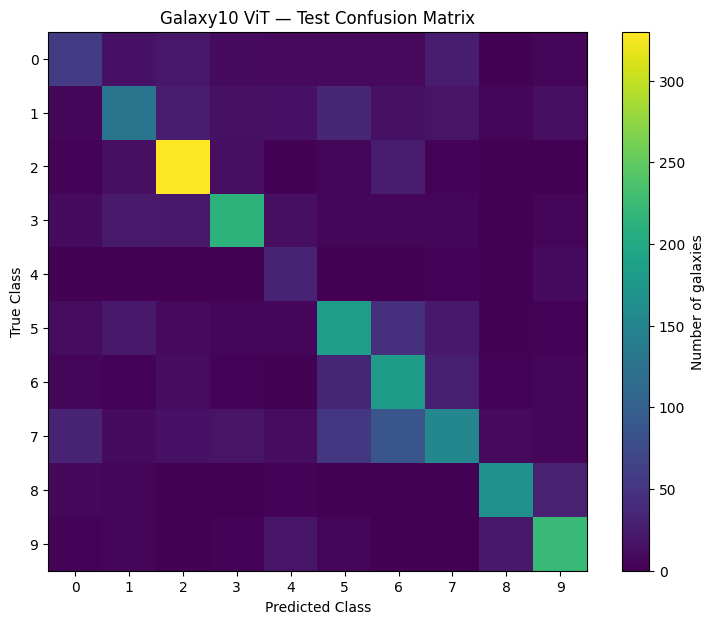

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

plt.imshow(cm)

plt.title("Galaxy10 ViT — Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(range(10))
plt.yticks(range(10))

plt.colorbar(label="Number of galaxies")

plt.show()

The rows represent the true galaxy classes and the columns represent the classes predicted by the Vision Transformer. The color intensity represents the number of galaxies in each cell, making the major correct classifications and recurring misclassifications easier to identify visually.

In [ ]:
misclassified = np.where(y_true != y_pred)[0]

print("Total test images:", len(y_true))
print("Misclassified images:", len(misclassified))
print("Correctly classified:", np.sum(y_true == y_pred))

Total test images: 2661
Misclassified images: 993
Correctly classified: 1668


Identifying the positions of all incorrectly classified test images by comparing y_true and y_pred. It then prints the total number of test images, the number that were misclassified, and the number that were classified correctly. This gives a simple numerical summary of the model's test performance.

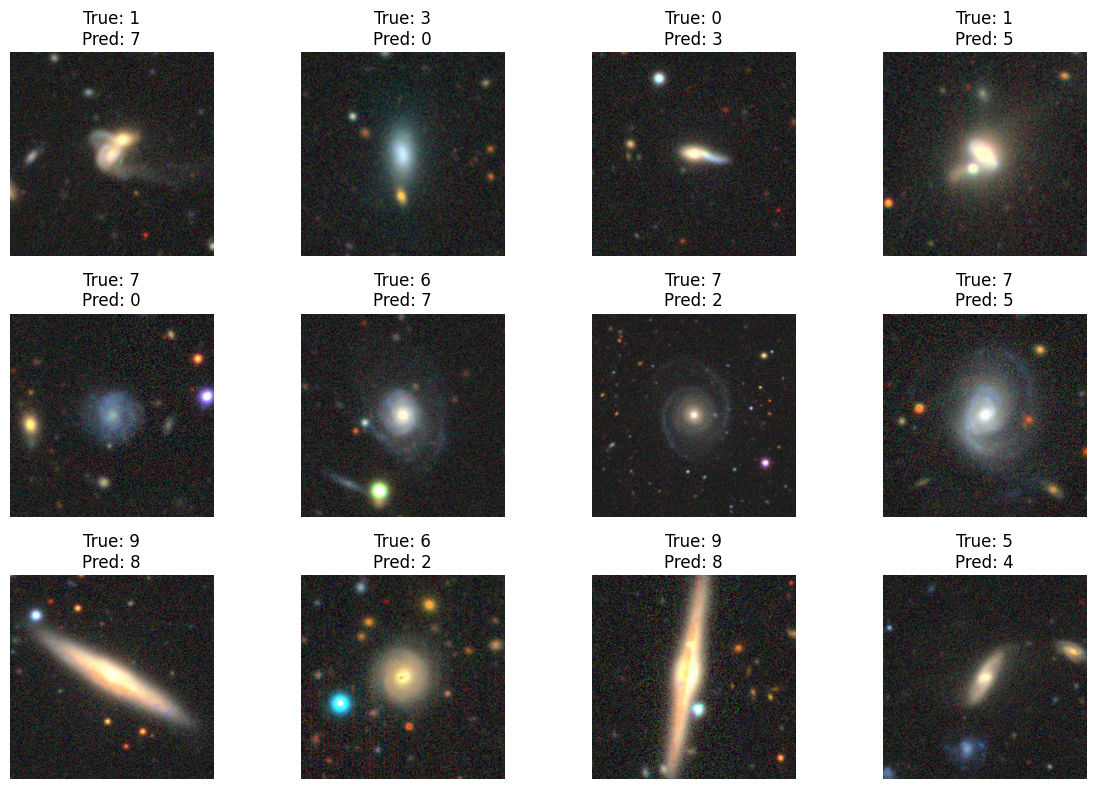

In [ ]:
plt.figure(figsize=(12, 8))

for i, idx in enumerate(misclassified[:12]):
    image, label = next(iter(create_dataset([test_idx[idx]], shuffle=False)))

    plt.subplot(3, 4, i + 1)
    plt.imshow(image[0])
    plt.title(f"True: {y_true[idx]}\nPred: {y_pred[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

For each image, it displays the galaxy along with its true class and the class predicted by the Vision Transformer. This allows the model's errors to be examined visually and helps identify whether the mistakes occur between galaxies with similar visual morphology.

In [ ]:
for true_class in range(10):
    row = cm[true_class].copy()
    row[true_class] = 0

    predicted_class = np.argmax(row)
    count = row[predicted_class]

    print(
        f"True class {true_class} → Predicted class {predicted_class}: {count} images"
    )

True class 0 → Predicted class 7: 26 images
True class 1 → Predicted class 5: 36 images
True class 2 → Predicted class 6: 27 images
True class 3 → Predicted class 1: 24 images
True class 4 → Predicted class 9: 10 images
True class 5 → Predicted class 6: 45 images
True class 6 → Predicted class 5: 34 images
True class 7 → Predicted class 6: 88 images
True class 8 → Predicted class 9: 30 images
True class 9 → Predicted class 8: 22 images


Examining the confusion matrix one true class at a time. It temporarily ignores the correct prediction for that class and finds the incorrect class that receives the largest number of predictions. Therefore, it identifies the most common incorrect prediction for each galaxy morphology class and prints the number of images involved.

In [ ]:
y_prob = []

for batch_images, batch_labels in test_ds:
    predictions = vit_model(batch_images, training=False)
    y_prob.extend(tf.reduce_max(predictions, axis=1).numpy())

y_prob = np.array(y_prob)

print("Confidence shape:", y_prob.shape)
print("Average confidence:", y_prob.mean())

Confidence shape: (2661,)
Average confidence: 0.68833536


prediction confidence analysis

calculating the model's confidence for every test image. For each prediction, the maximum probability among the ten output classes is taken as the model's confidence in its predicted class. These confidence values are collected into y_prob, and the average confidence across the entire test set is then calculated.

In [ ]:
correct_mask = (y_true == y_pred)

correct_confidence = y_prob[correct_mask]
wrong_confidence = y_prob[~correct_mask]

print("Average confidence — correct:", correct_confidence.mean())
print("Average confidence — wrong:", wrong_confidence.mean())

Average confidence — correct: 0.759151
Average confidence — wrong: 0.5693823


Separating the confidence values into two groups: correctly classified images and incorrectly classified images. It then calculates the average confidence for each group. This allows us to determine whether the model generally expresses greater confidence when its predictions are correc

In [ ]:
high_conf_wrong = np.sum(
    (y_true != y_pred) & (y_prob >= 0.80)
)

print("Wrong predictions with >=80% confidence:", high_conf_wrong)
print(
    "Percentage of wrong predictions:",
    high_conf_wrong / np.sum(y_true != y_pred) * 100
)

Wrong predictions with >=80% confidence: 150
Percentage of wrong predictions: 15.105740181268882


Counting the incorrectly classified images for which the model was still at least 80% confident. It then calculates what percentage of all incorrect predictions these high-confidence mistakes represent. This is useful because a wrong prediction made with high confidence is different from an error where the model was obviously uncertain.

In [ ]:
high_conf_correct = np.sum(
    (y_true == y_pred) & (y_prob >= 0.80)
)

print("Correct predictions with >=80% confidence:", high_conf_correct)
print(
    "Percentage of correct predictions:",
    high_conf_correct / np.sum(y_true == y_pred) * 100
)

Correct predictions with >=80% confidence: 868
Percentage of correct predictions: 52.038369304556355


performing the corresponding analysis for correctly classified images. It counts how many correct predictions had confidence of at least 80% and calculates what percentage of all correct predictions reached this confidence level

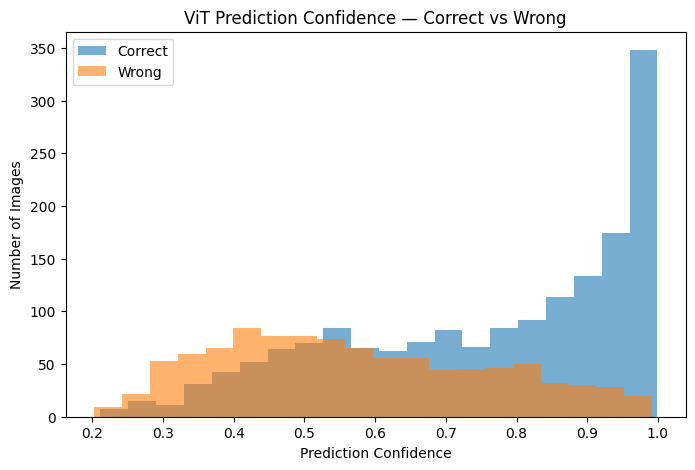

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    correct_confidence,
    bins=20,
    alpha=0.6,
    label="Correct"
)

plt.hist(
    wrong_confidence,
    bins=20,
    alpha=0.6,
    label="Wrong"
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Images")
plt.title("ViT Prediction Confidence — Correct vs Wrong")
plt.legend()
plt.show()

creating two overlapping histograms showing the confidence distributions of correct and incorrect predictions. The x-axis represents prediction confidence and the y-axis represents the number of images. The plot makes it possible to visually compare how confidently the Vision Transformer makes correct predictions versus incorrect predictions.

**Overall** **interpretation**

The Vision Transformer achieved 62.68% accuracy and a weighted F1-score of 0.6233 on the held-out Galaxy10 test set. Performance varied substantially across morphology classes, with several classes achieving F1-scores above 0.75 while others remained more challenging. The confusion matrix revealed recurring confusion between specific morphology classes, suggesting that visually similar galaxy structures remain difficult for the relatively compact ViT architecture. Confidence analysis showed that correct predictions had substantially higher average confidence (75.9%) than incorrect predictions (56.9%). However, 15.1% of incorrect predictions were made with at least 80% confidence, indicating that some errors were not simply low-confidence cases but potentially difficult or ambiguous morphological classifications.



**Final Training Accuracy:** 66.44% **Final Validation Accuracy:** 64.59%

The custom Vision Transformer successfully learned galaxy morphological representations from scratch, improving from an initial ~10% random baseline to ~64.6% validation accuracy.